In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
connection = sqlite3.connect("data/all_hiski_records.sqlite3")
cursor = connection.cursor()

In [3]:
query = """
    SELECT *
    FROM parish;
"""

cursor.execute(query)

parish_id_to_place = {
    row[0]: {
        "province": row[1],
        "name": row[2],
        "namese": row[3],
        "xpos": row[4],
        "ypos": row[5],
        "lon": row[6],
        "lat": row[7],
        "history": row[8],
    }
    for row in cursor.fetchall()
}

## Total number of parishes in database

In [4]:
query = """
    SELECT parish_id, COUNT(parish_id)
    FROM immigrated
    GROUP BY parish_id;
"""

cursor.execute(query)

immigration_parish_event_counts = cursor.fetchall()
immigration_parish_event_counts = pd.DataFrame(
    immigration_parish_event_counts, columns=["parish_id", "count"]
)


query = """
    SELECT parish_id, COUNT(parish_id)
    FROM emigrated
    GROUP BY parish_id;
"""

cursor.execute(query)

emigration_parish_event_counts = cursor.fetchall()
emigration_parish_event_counts = pd.DataFrame(
    emigration_parish_event_counts, columns=["parish_id", "count"]
)

In [5]:
immigration_parish_event_counts["name"] = immigration_parish_event_counts[
    "parish_id"
].map(lambda p_id: parish_id_to_place.get(p_id, {"name": "unknown"})["name"])
emigration_parish_event_counts["name"] = emigration_parish_event_counts[
    "parish_id"
].map(lambda p_id: parish_id_to_place.get(p_id, {"name": "unknown"})["name"])

In [6]:
print(
    "Number of",
    f" - parishes in parishes-table: {len(
        parish_id_to_place
    )}",
    f" - parishes not in parishes-table: {
        len(
            set(immigration_parish_event_counts["parish_id"].unique()).union(
                set(emigration_parish_event_counts["parish_id"].unique())
            ).difference(set(parish_id_to_place.keys())
        )
    )}",
    f" - parishes in immigrated-table: {len(
        immigration_parish_event_counts["parish_id"].unique()
    )}",
    f" - parishes in emigrated-table: {len(
        emigration_parish_event_counts["parish_id"].unique()
    )}",
    f" - parishes not in common between immigrated-table and emigrated-table: {
        len(set(immigration_parish_event_counts["parish_id"].unique()).symmetric_difference(
            set(emigration_parish_event_counts["parish_id"].unique()
        ))
    )}",
    sep="\n"
)

Number of
 - parishes in parishes-table: 522
 - parishes not in parishes-table: 1
 - parishes in immigrated-table: 166
 - parishes in emigrated-table: 166
 - parishes not in common between immigrated-table and emigrated-table: 22


## Distribution of events between parishes in database

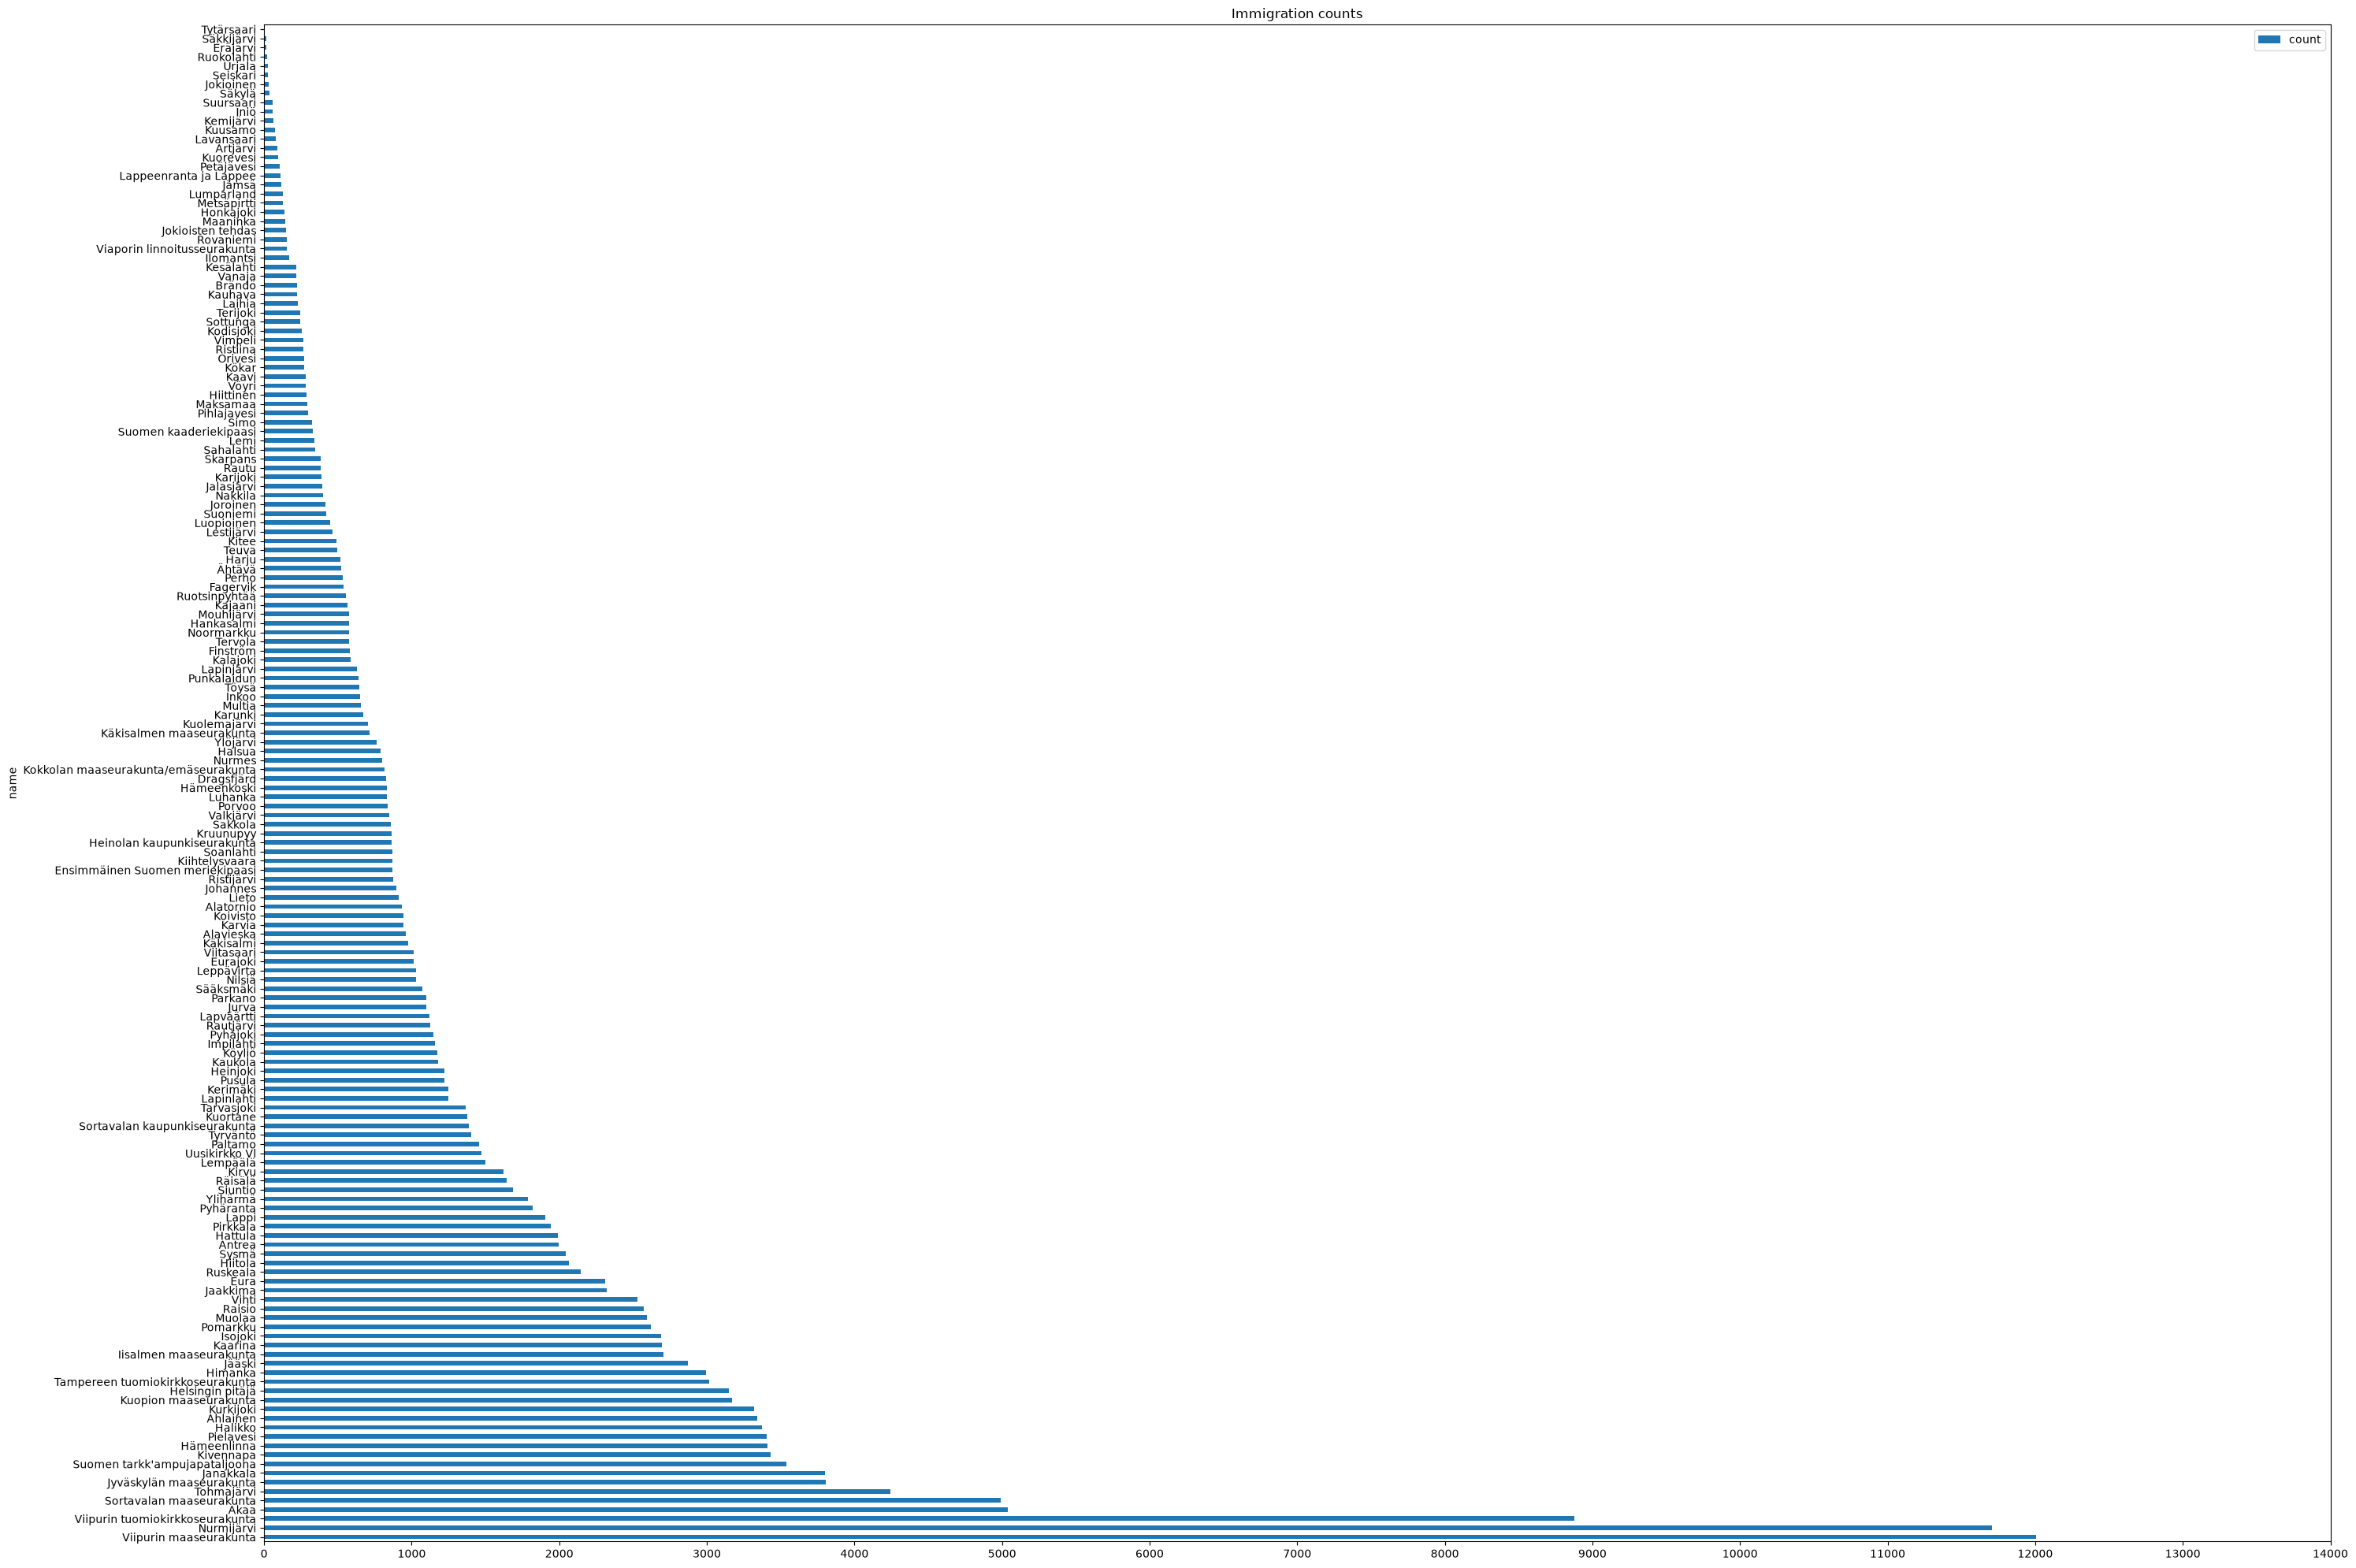

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
immigration_parish_event_counts.sort_values(
    "count", ascending=False
).plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
ax.set_title("Immigration counts")
fig.tight_layout()

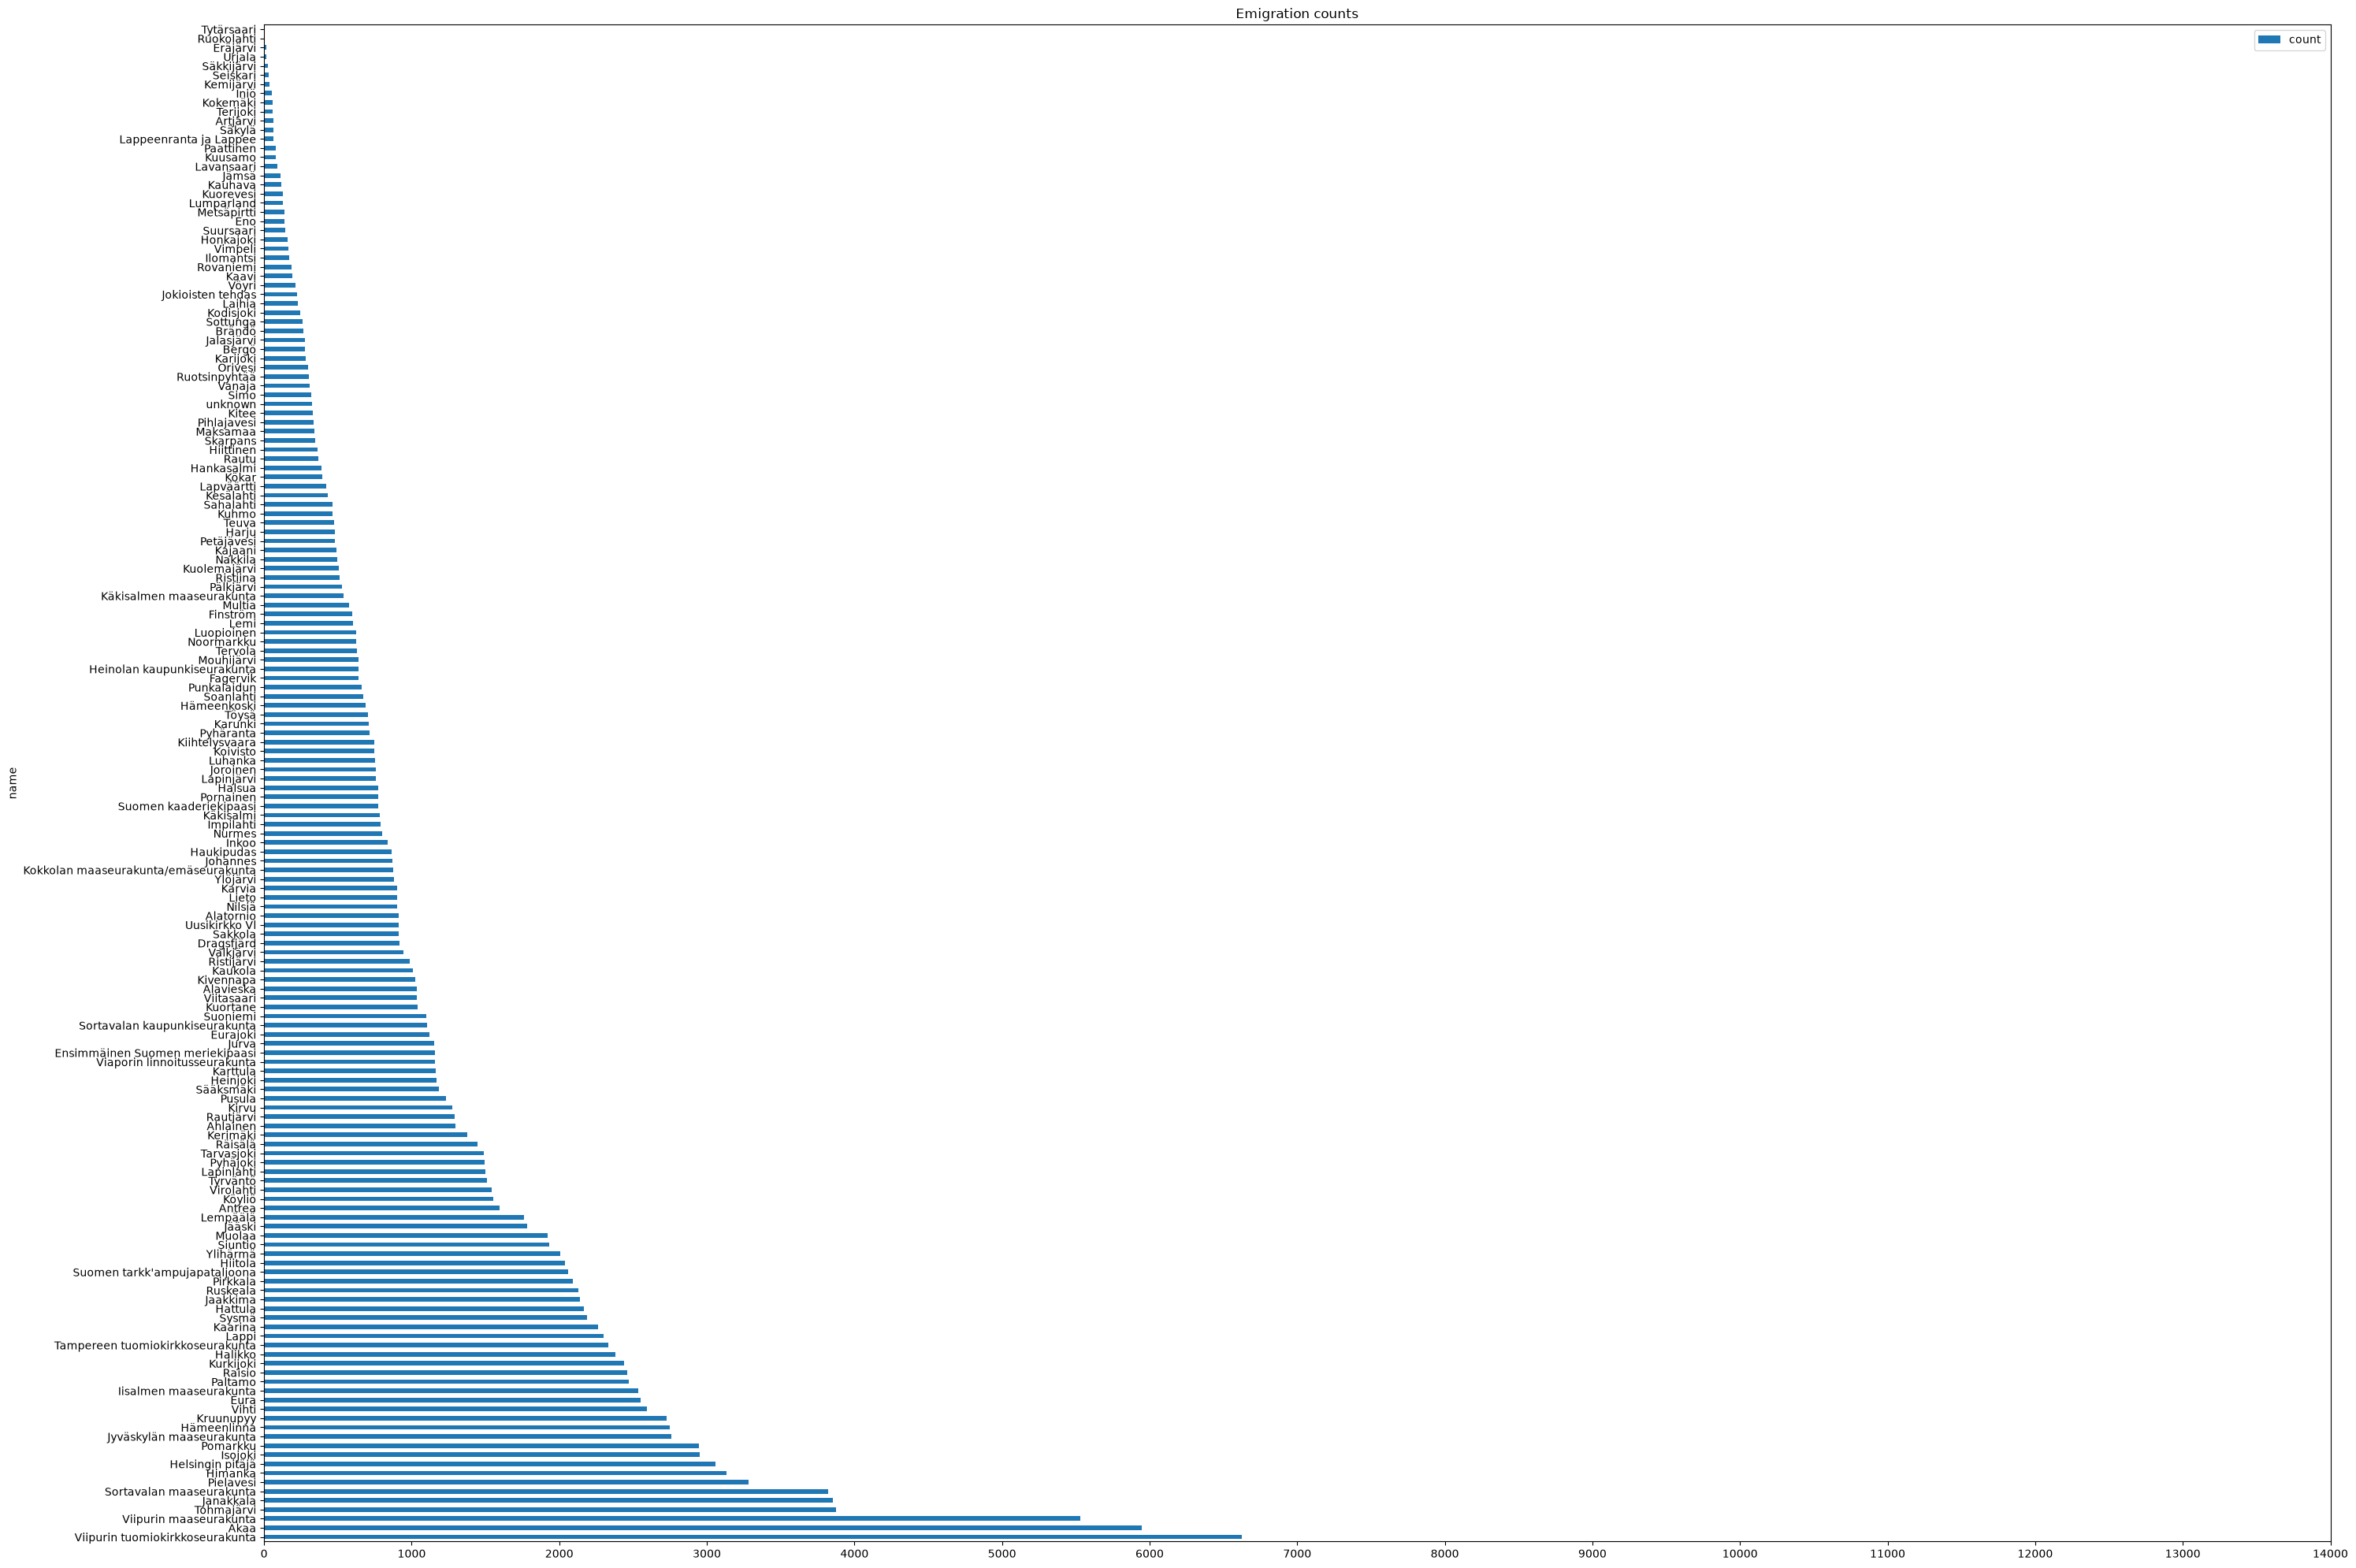

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
emigration_parish_event_counts.sort_values(
    "count", ascending=False
).plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
ax.set_title("Emigration counts")
fig.tight_layout()

### Top 25 parishes

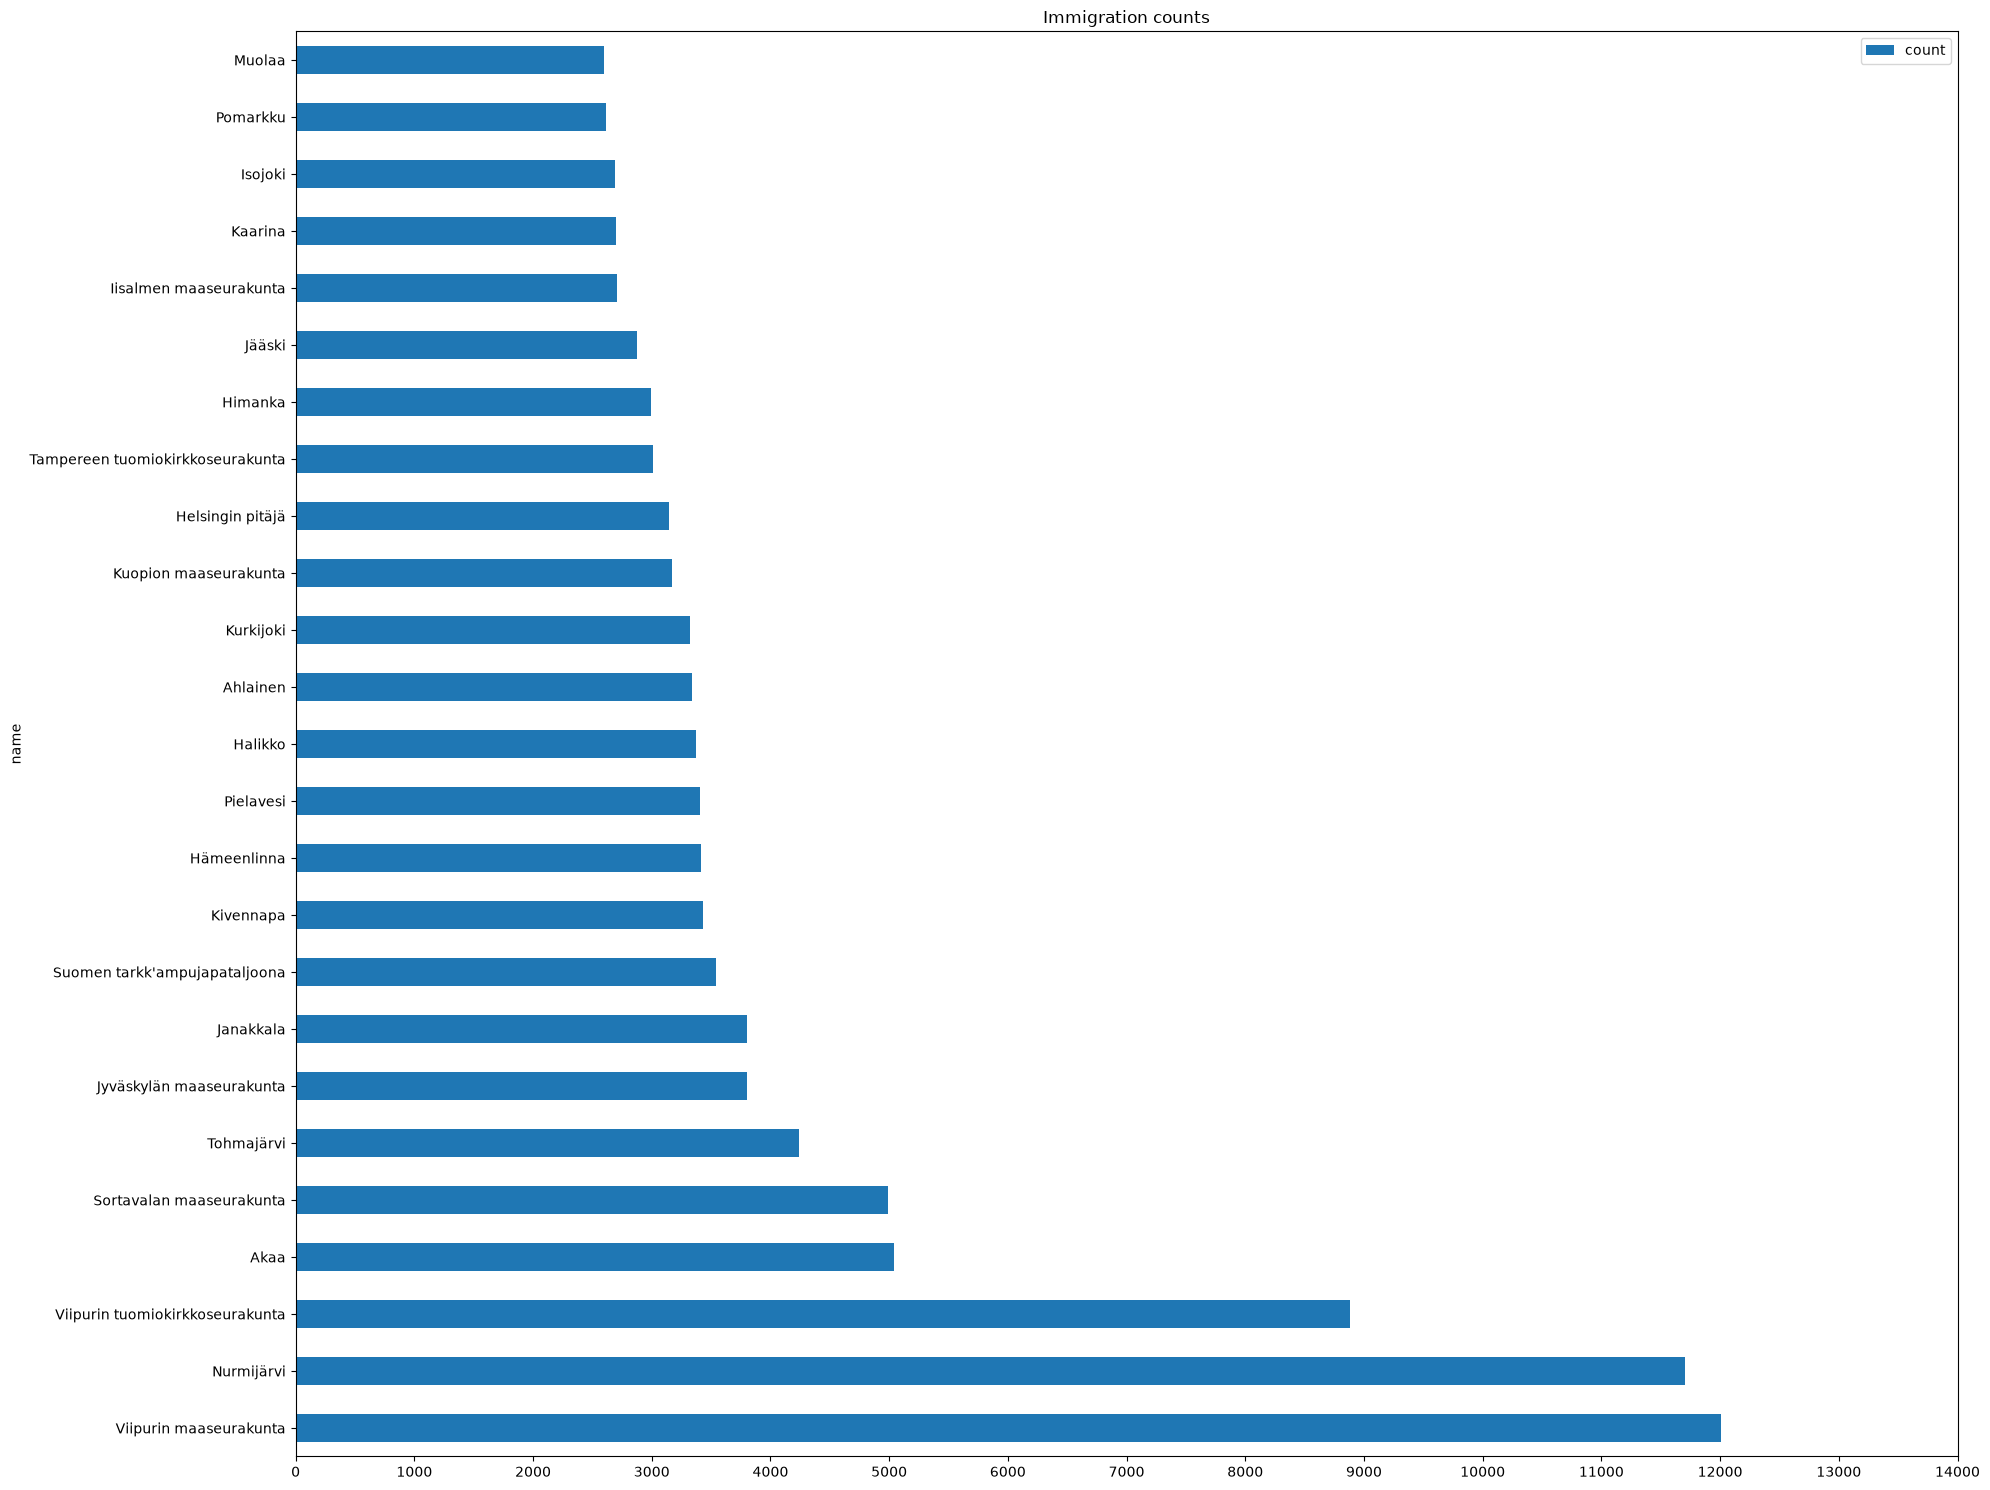

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
immigration_parish_event_counts.sort_values(
    "count", ascending=False
)[:25].plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
ax.set_title("Immigration counts")
fig.tight_layout()

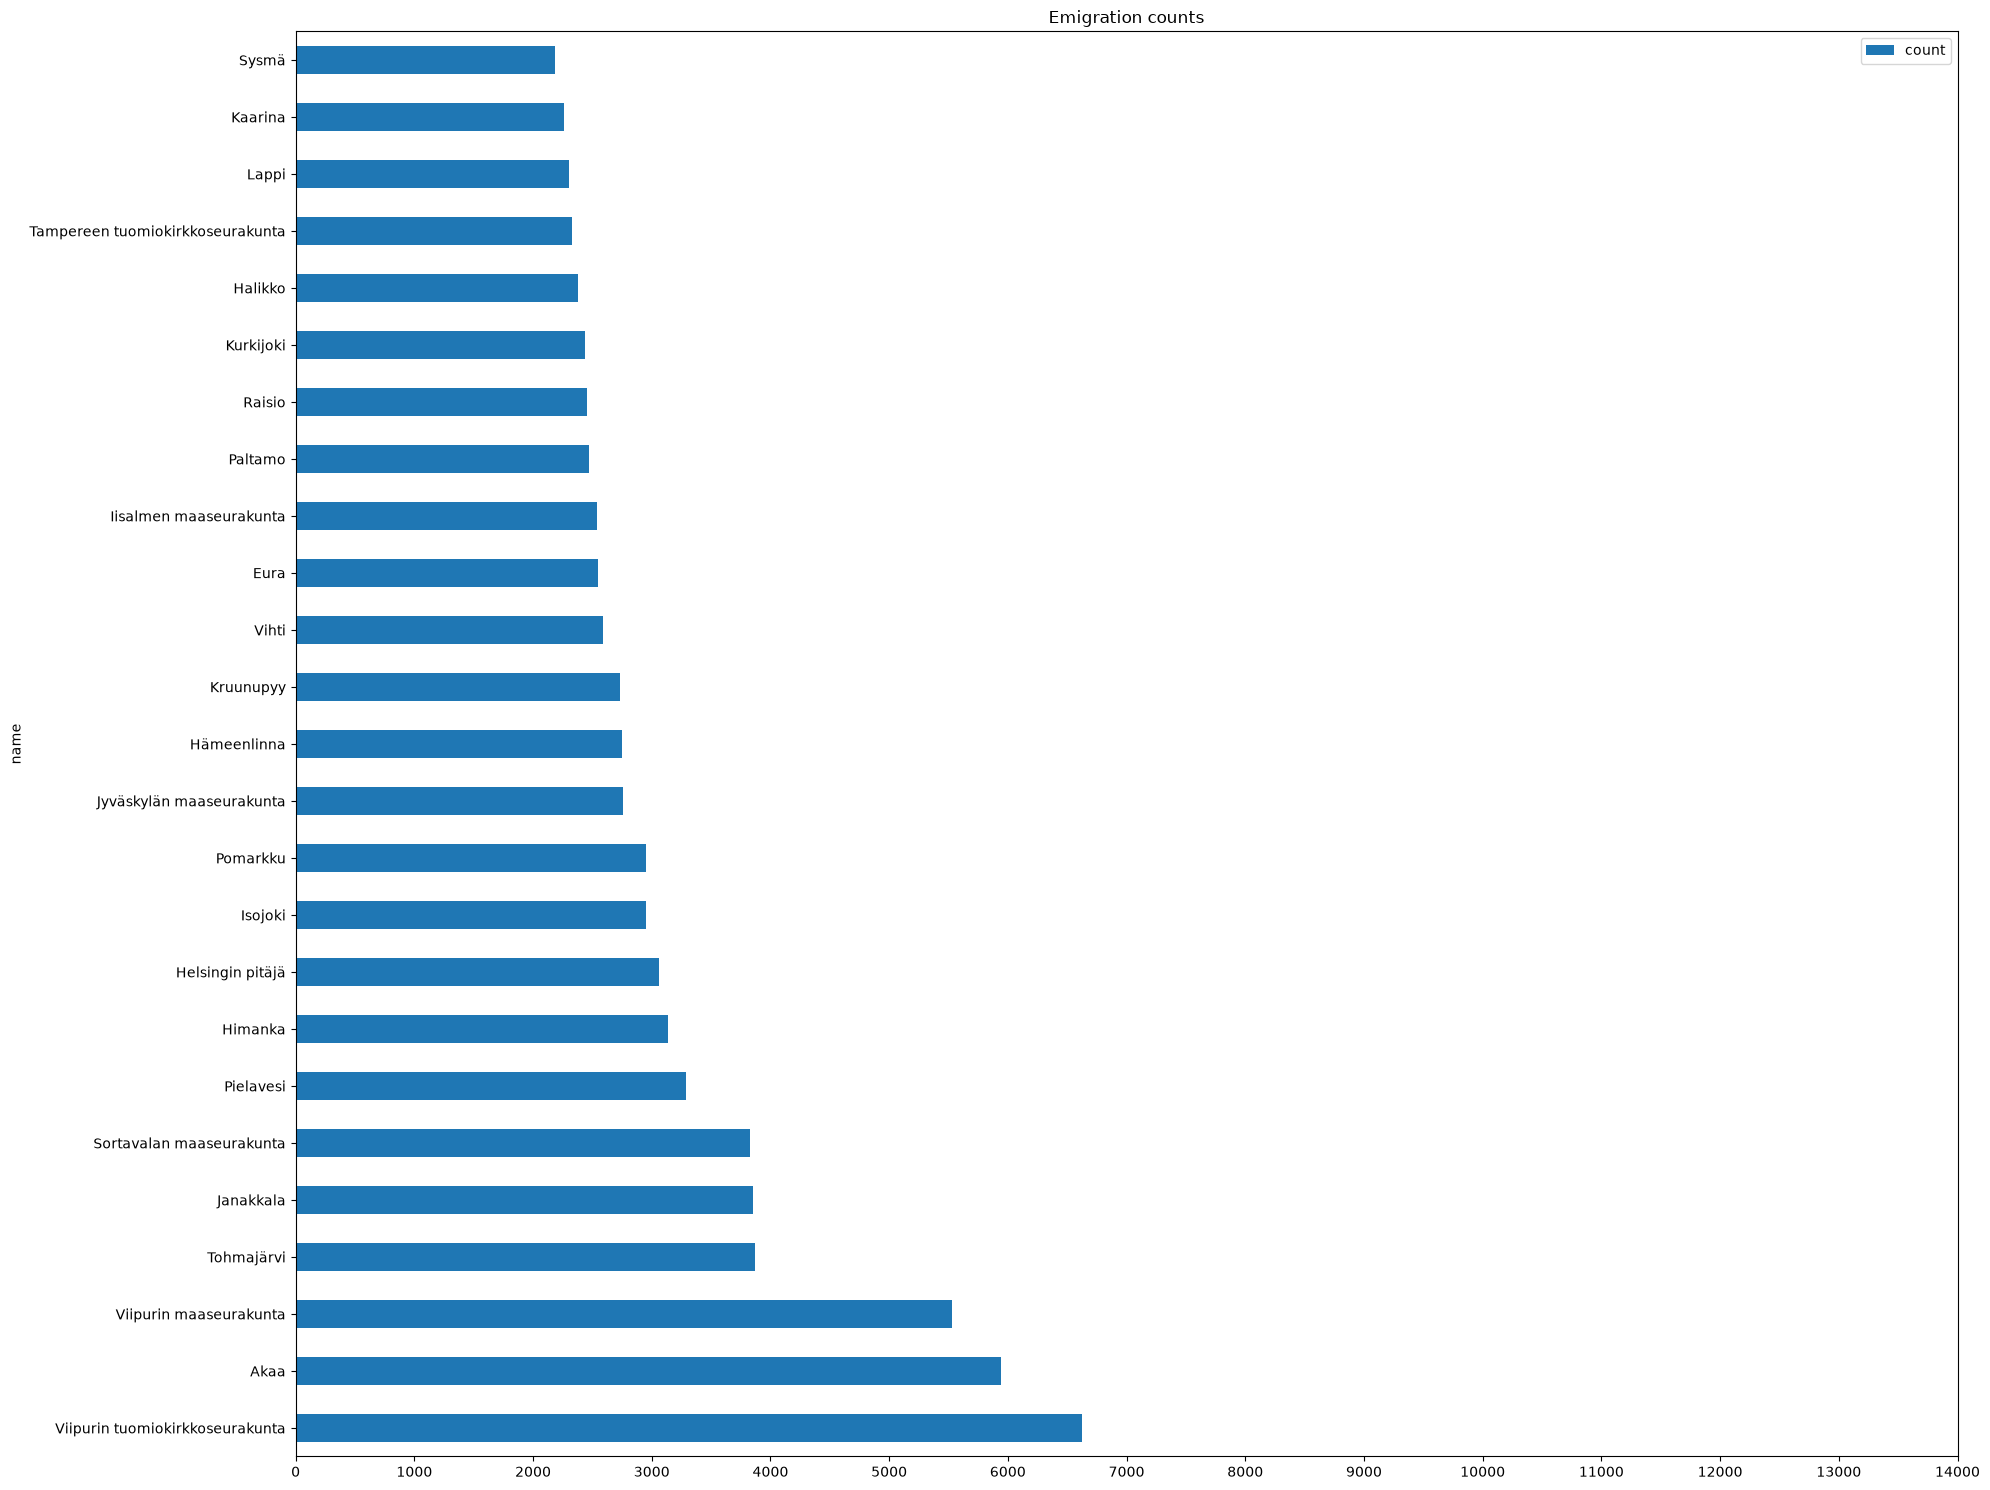

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(20, 15))
emigration_parish_event_counts.sort_values(
    "count", ascending=False
)[:25].plot.barh(y="count", x="name", ax=ax)
ax.set_xticks(range(0, 15000, 1000), range(0, 15000, 1000))
ax.set_title("Emigration counts")
fig.tight_layout()

## Parish events on map

In [11]:
immigration_parish_e_counts_with_coordinates = (
    immigration_parish_event_counts.copy()
)
immigration_parish_e_counts_with_coordinates["lon"] = (
    immigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
immigration_parish_e_counts_with_coordinates["lat"] = (
    immigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)


emigration_parish_e_counts_with_coordinates = (
    emigration_parish_event_counts.copy()
)
emigration_parish_e_counts_with_coordinates["lon"] = (
    emigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lon": None})["lon"]
    )
)
emigration_parish_e_counts_with_coordinates["lat"] = (
    emigration_parish_e_counts_with_coordinates["parish_id"].map(
        lambda x: parish_id_to_place.get(x, {"lat": None})["lat"]
    )
)

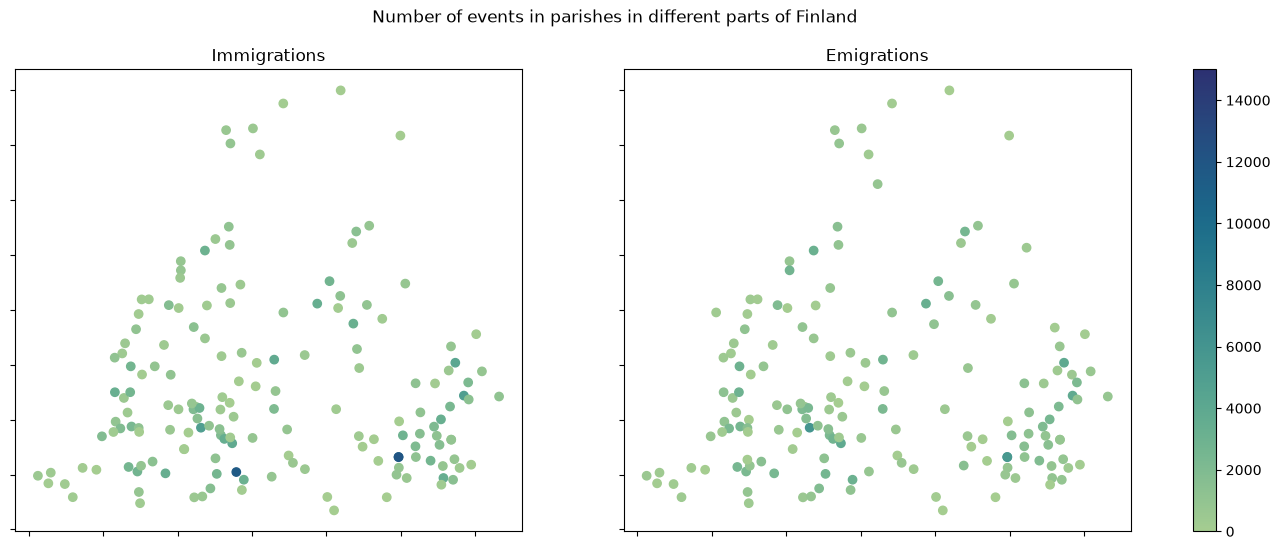

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Number of events in parishes in different parts of Finland")
axs[0].scatter(
    x=immigration_parish_e_counts_with_coordinates["lon"],
    y=immigration_parish_e_counts_with_coordinates["lat"],
    c=immigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=15000
)
axs[0].set_yticklabels([])
axs[0].set_xticklabels([])
axs[0].set_title("Immigrations")

scatter = axs[1].scatter(
    x=emigration_parish_e_counts_with_coordinates["lon"],
    y=emigration_parish_e_counts_with_coordinates["lat"],
    c=emigration_parish_e_counts_with_coordinates["count"],
    cmap=sns.cm.crest,
    vmin=0, vmax=15000
)
axs[1].set_yticklabels([])
axs[1].set_xticklabels([])
axs[1].set_title("Emigrations")
fig.colorbar(scatter, ax=axs, fraction=0.05)

## Placename mapping

```json
"Helsinki": [
    "Helsinki kaup.": [
        ["Helsinginkaupunki", 0.6470588235294117, 2],
        ["HelsinkinKaupunki", 0.6470588235294117, 1],
        ["Kelsinkinkaupunki", 0.6470588235294117, 1],
        ["Helsingikaupunki", 0.625, 1],
        ["HelsinkinKaupan ki", 0.6111111111111112, 1]
    ],
    "Helsinkiin": [
        ["Helsinkiin", 1.0, 11],
        ["Helsinki", 0.8, 4],
        ["Helinkiin", 0.9, 1],
        ["Helsmäki", 0.6, 1],
        ["Holpikiin", 0.7, 1],
        ...
    ],
    ...
],
"Sastmola": [
    "Sastmåla": [
        ["Tapomäla", 0.5, 1],
        ["Fastmäla", 0.75, 1],
        ["Fastmäla.", 0.6666666666666667, 1],
        ["Sapmala", 0.625, 1],
        ["Sapmäla", 0.625, 1],
        ...
    ],
    "Sastmola": [
        ["Sastmola", 1.0, 34],
        ["Sallmola", 0.75, 25],
        ["Sallmala", 0.625, 7],
        ["Fastmola", 0.875, 6],
        ["Sastmula", 0.875, 3],
        ...
    ],
    "Sastm.": [
        ["Sastm:", 0.8333333333333334, 3],
        ["Sastmola", 0.625, 2],
        ["Tamm.", 0.5, 1],
        ["Sastamm", 0.7142857142857143, 1]
    ],
    ...
]
```